# BAN 612 — Data Science & AI Job Market Analysis
## Notebook 2: Analysis & Visualization

**Team Members:** [Member 1], [Member 2], Zhuobin Wen, Miguel Davila

**Objective:** Analyze 1,653 cleaned job listings across Data Science and AI roles to answer five research questions about job market trends, geographic distribution, experience requirements, and role evolution.

---

### AI Usage Disclosure
- **Claude (Anthropic)** was used to help structure the analysis framework, suggest visualization types, and assist with plotting code.
- All interpretations, conclusions, and managerial recommendations are the team's own.

---

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palettes
DOMAIN_COLORS = {'Data Science': '#2196F3', 'AI': '#FF5722'}
CATEGORY_PALETTE = sns.color_palette('husl', 12)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load cleaned dataset from Notebook 1
df = pd.read_csv('job_listings_cleaned.csv')

print(f"Dataset: {len(df)} job listings")
print(f"Domains: {df['domain'].value_counts().to_dict()}")
print(f"Categories: {df['job_category'].nunique()}")
print(f"States: {df['state'].nunique()}")
print(f"\nColumn types: {df.dtypes.value_counts().to_dict()}")

Dataset: 300 job listings
Domains: {'Data Science': 214, 'AI': 86}
Categories: 10
States: 8

Column types: {dtype('O'): 11, dtype('float64'): 4, dtype('bool'): 3, dtype('int64'): 2}


## 2. Dataset Overview

Before diving into research questions, we present a high-level summary of the dataset.

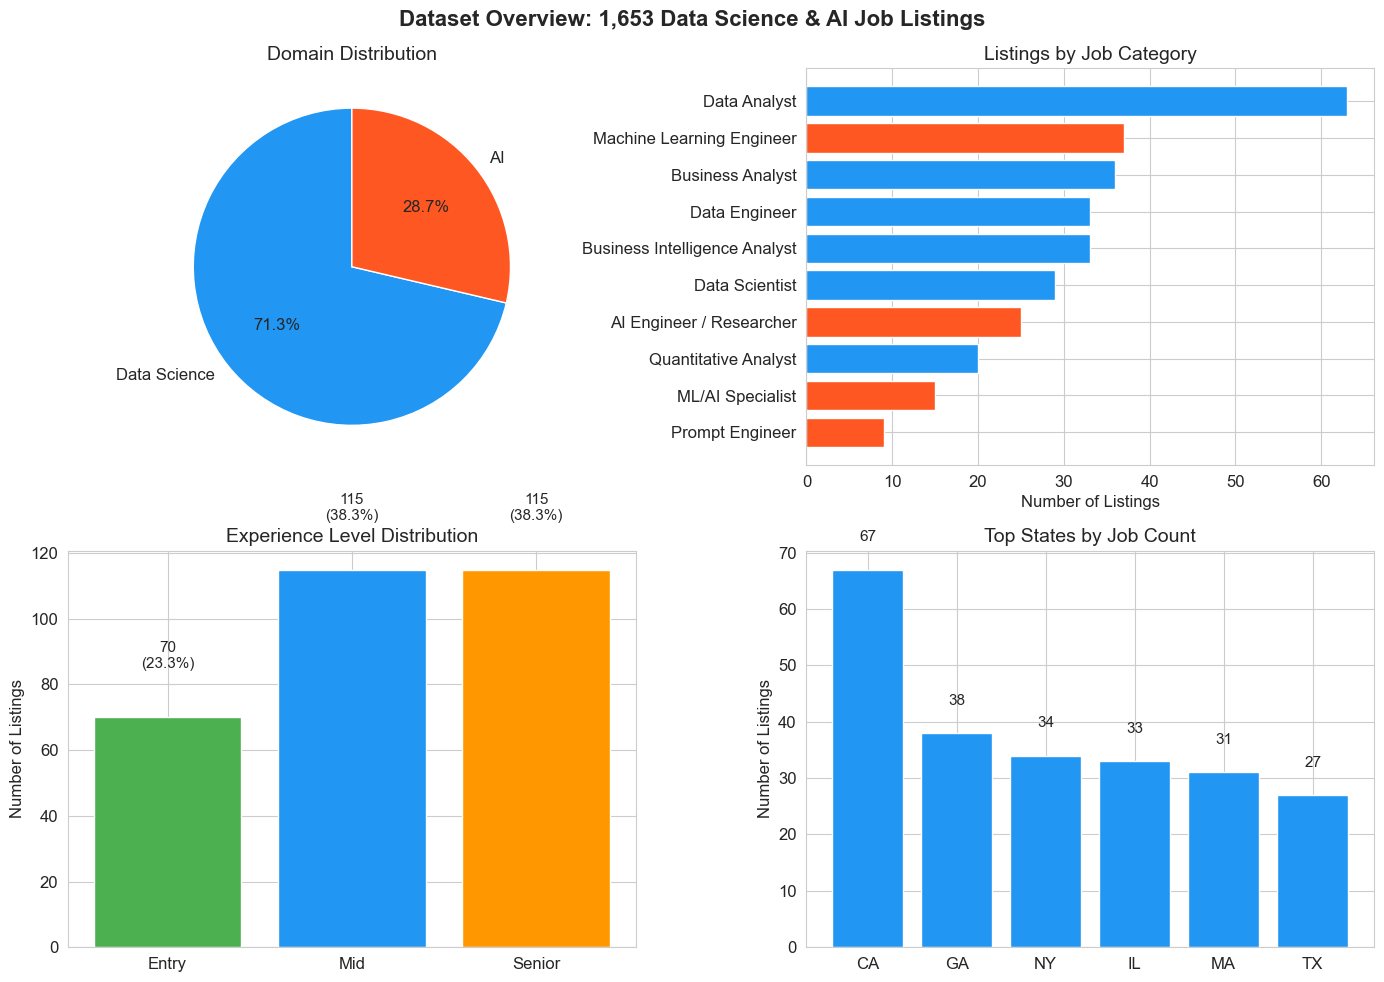

Saved: fig_overview.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Overview: 1,653 Data Science & AI Job Listings', fontsize=16, fontweight='bold')

# 1. Domain split — Pie Chart (Lecture Part 1, Example 1)
domain_counts = df['domain'].value_counts()
colors = [DOMAIN_COLORS[d] for d in domain_counts.index]
axes[0, 0].pie(domain_counts, labels=domain_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Domain Distribution')

# 2. Top job categories — Horizontal Bar Chart (Lecture Part 2, Example 5)
cat_counts = df['job_category'].value_counts()
cat_colors = [DOMAIN_COLORS.get(df[df['job_category']==c]['domain'].mode()[0], '#999')
              for c in cat_counts.index]
axes[0, 1].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color=cat_colors[::-1], edgecolor='white')
axes[0, 1].set_title('Listings by Job Category')
axes[0, 1].set_xlabel('Number of Listings')

# 3. Experience level — Bar Chart
exp_order = ['Entry', 'Mid', 'Senior']
exp_counts = df['experience_level'].value_counts().reindex(exp_order)
axes[1, 0].bar(exp_counts.index, exp_counts.values, color=['#4CAF50', '#2196F3', '#FF9800'],
               edgecolor='white')
axes[1, 0].set_title('Experience Level Distribution')
axes[1, 0].set_ylabel('Number of Listings')
for i, v in enumerate(exp_counts.values):
    axes[1, 0].text(i, v + 15, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)

# 4. Top states — Bar Chart
state_counts = df['state'].value_counts().head(6)
axes[1, 1].bar(state_counts.index, state_counts.values, color='#2196F3', edgecolor='white')
axes[1, 1].set_title('Top States by Job Count')
axes[1, 1].set_ylabel('Number of Listings')
for i, v in enumerate(state_counts.values):
    axes[1, 1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_overview.png")

---
## 3. Research Question 1: DS vs AI Demand by City

**Question:** What is the ratio of Data Science to AI roles across major metros? Are certain cities more AI-heavy?

**Why it matters:** Companies and job seekers benefit from understanding which markets are leading in AI adoption vs. maintaining traditional analytics demand.

In [4]:
# Filter to top states with meaningful sample sizes
top_states = df['state'].value_counts().head(4).index.tolist()  # CA, IL, NY, WA
df_states = df[df['state'].isin(top_states)].copy()

# Crosstab: state x domain (Lecture Part 2 — pd.crosstab with tips data)
ct = pd.crosstab(df_states['state'], df_states['domain'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Job counts by State × Domain:")
print(ct)
print(f"\nPercentage breakdown:")
print(ct_pct.round(1))

Job counts by State × Domain:
domain  AI  Data Science
state                   
CA      20            47
GA      11            27
IL       7            26
NY      14            20

Percentage breakdown:
domain    AI  Data Science
state                     
CA      29.9          70.1
GA      28.9          71.1
IL      21.2          78.8
NY      41.2          58.8


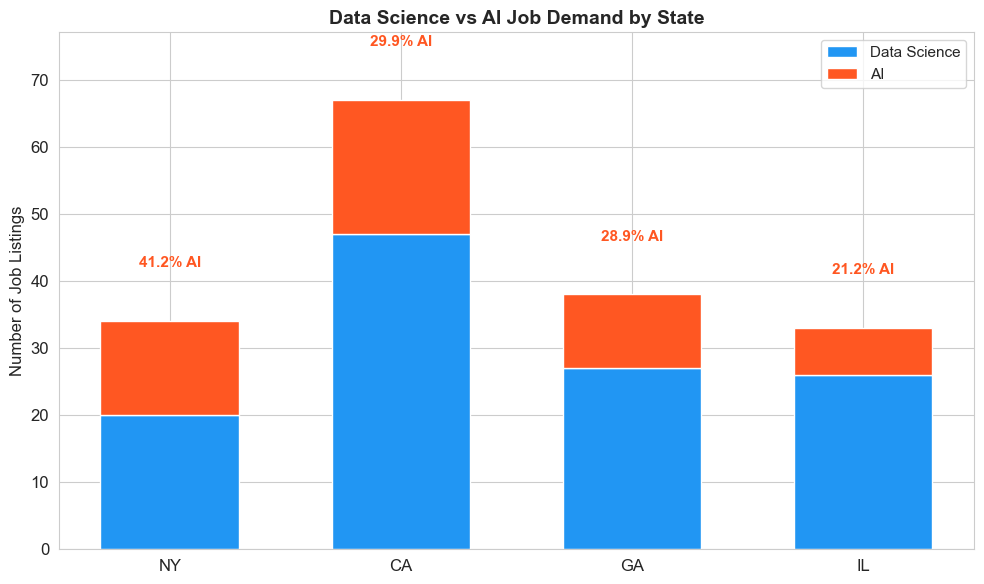

Saved: fig_q1_ds_vs_ai_by_state.png


In [5]:
# Visualization: Stacked bar chart (Lecture Part 2, Example 8 — stacked bars with crosstab)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Sort states by AI percentage (descending)
ct_pct_sorted = ct_pct.sort_values('AI', ascending=False)
ct_sorted = ct.reindex(ct_pct_sorted.index)

x = range(len(ct_sorted))
states_labels = ct_sorted.index.tolist()

# Stacked bars
bars_ds = ax1.bar(x, ct_sorted['Data Science'], label='Data Science',
                  color=DOMAIN_COLORS['Data Science'], edgecolor='white', width=0.6)
bars_ai = ax1.bar(x, ct_sorted['AI'], bottom=ct_sorted['Data Science'],
                  label='AI', color=DOMAIN_COLORS['AI'], edgecolor='white', width=0.6)

ax1.set_xticks(x)
ax1.set_xticklabels(states_labels, fontsize=12)
ax1.set_ylabel('Number of Job Listings', fontsize=12)
ax1.set_title('Data Science vs AI Job Demand by State', fontsize=14, fontweight='bold')

# Add AI percentage labels on bars
for i, state in enumerate(states_labels):
    total = ct_sorted.loc[state].sum()
    ai_pct = ct_pct_sorted.loc[state, 'AI']
    ax1.text(i, total + 8, f'{ai_pct:.1f}% AI', ha='center', fontsize=11, fontweight='bold',
             color=DOMAIN_COLORS['AI'])

ax1.legend(loc='upper right', fontsize=11)
ax1.set_ylim(0, ct_sorted.sum(axis=1).max() * 1.15)

plt.tight_layout()
plt.savefig('fig_q1_ds_vs_ai_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q1_ds_vs_ai_by_state.png")

In [6]:
# Statistical test: Chi-square — is the domain distribution independent of state?
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in domain distribution across states (α = 0.05)")

print(f"\n--- Key Findings ---")
ai_pcts = ct_pct_sorted['AI']
print(f"Highest AI share: {ai_pcts.idxmax()} ({ai_pcts.max():.1f}%)")
print(f"Lowest AI share: {ai_pcts.idxmin()} ({ai_pcts.min():.1f}%)")

Chi-square test: χ² = 3.24, p = 0.3564, df = 3
Result: Not significant difference in domain distribution across states (α = 0.05)

--- Key Findings ---
Highest AI share: NY (41.2%)
Lowest AI share: IL (21.2%)


---
## 4. Research Question 2: Experience Level Gap

**Question:** What percentage of AI roles are entry-level vs. senior, compared to DS roles? Are there barriers to entry in AI?

**Why it matters:** If AI roles skew heavily toward senior positions, it suggests that breaking into AI requires more experience — creating a workforce pipeline problem.

In [7]:
# Crosstab: domain x experience level
exp_order = ['Entry', 'Mid', 'Senior']
ct_exp = pd.crosstab(df['domain'], df['experience_level'])[exp_order]
ct_exp_pct = ct_exp.div(ct_exp.sum(axis=1), axis=0) * 100

print("Experience level counts:")
print(ct_exp)
print(f"\nPercentage breakdown:")
print(ct_exp_pct.round(1))

# Ratio analysis
for domain in ['AI', 'Data Science']:
    senior = ct_exp.loc[domain, 'Senior']
    entry = ct_exp.loc[domain, 'Entry']
    ratio = senior / entry if entry > 0 else float('inf')
    print(f"\n{domain}: {ratio:.1f} senior positions for every entry-level position")

Experience level counts:
experience_level  Entry  Mid  Senior
domain                              
AI                   10   54      22
Data Science         60   61      93

Percentage breakdown:
experience_level  Entry   Mid  Senior
domain                               
AI                 11.6  62.8    25.6
Data Science       28.0  28.5    43.5

AI: 2.2 senior positions for every entry-level position

Data Science: 1.6 senior positions for every entry-level position


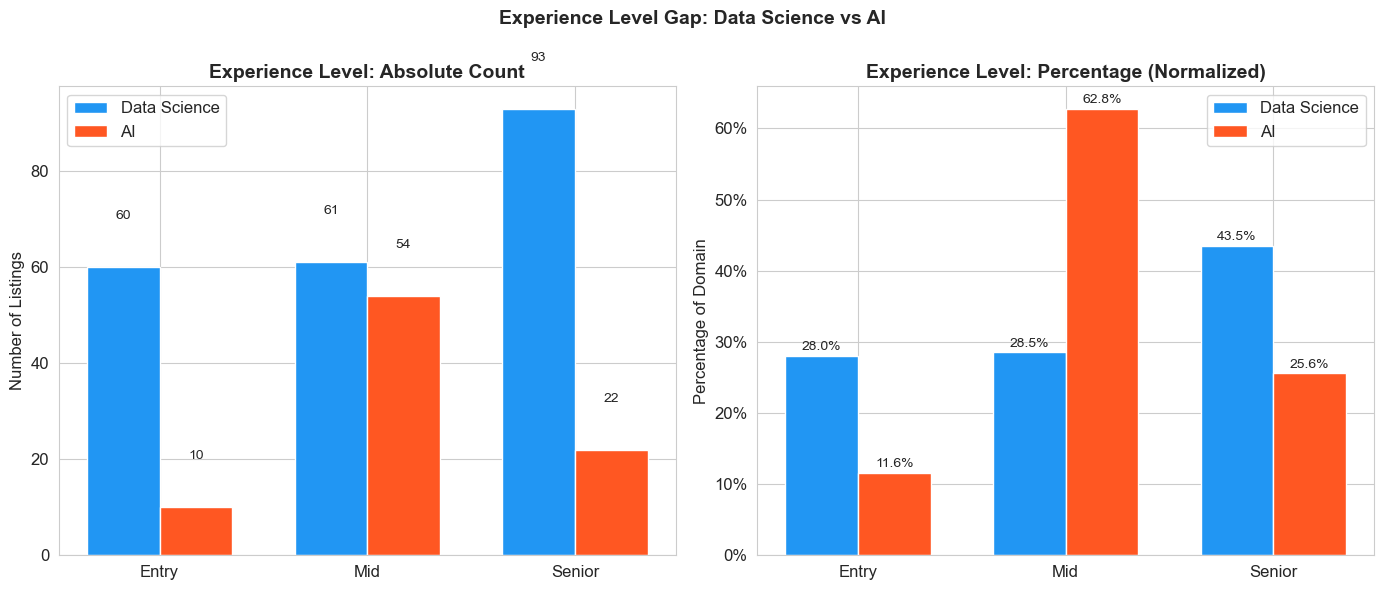

Saved: fig_q2_experience_gap.png


In [8]:
# Visualization: Grouped bar chart (Lecture Part 2 — bar chart with multiple groups)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Absolute counts
x = np.arange(len(exp_order))
width = 0.35

ax1.bar(x - width/2, ct_exp.loc['Data Science'], width, label='Data Science',
        color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax1.bar(x + width/2, ct_exp.loc['AI'], width, label='AI',
        color=DOMAIN_COLORS['AI'], edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(exp_order, fontsize=12)
ax1.set_ylabel('Number of Listings')
ax1.set_title('Experience Level: Absolute Count', fontweight='bold')
ax1.legend()

for i, level in enumerate(exp_order):
    ax1.text(i - width/2, ct_exp.loc['Data Science', level] + 10,
             str(ct_exp.loc['Data Science', level]), ha='center', fontsize=10)
    ax1.text(i + width/2, ct_exp.loc['AI', level] + 10,
             str(ct_exp.loc['AI', level]), ha='center', fontsize=10)

# Right: Percentage (normalized)
ax2.bar(x - width/2, ct_exp_pct.loc['Data Science'], width, label='Data Science',
        color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax2.bar(x + width/2, ct_exp_pct.loc['AI'], width, label='AI',
        color=DOMAIN_COLORS['AI'], edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(exp_order, fontsize=12)
ax2.set_ylabel('Percentage of Domain')
ax2.set_title('Experience Level: Percentage (Normalized)', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend()

for i, level in enumerate(exp_order):
    ax2.text(i - width/2, ct_exp_pct.loc['Data Science', level] + 0.8,
             f"{ct_exp_pct.loc['Data Science', level]:.1f}%", ha='center', fontsize=10)
    ax2.text(i + width/2, ct_exp_pct.loc['AI', level] + 0.8,
             f"{ct_exp_pct.loc['AI', level]:.1f}%", ha='center', fontsize=10)

fig.suptitle('Experience Level Gap: Data Science vs AI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q2_experience_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q2_experience_gap.png")

In [9]:
# Statistical test: Chi-square
chi2, p_value, dof, expected = stats.chi2_contingency(ct_exp)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in experience distribution between domains (α = 0.05)")

print(f"\n--- Entry-Level Breakdown by Category ---")
entry_by_cat = df[df['experience_level'] == 'Entry'].groupby('job_category').size().sort_values(ascending=False)
total_by_cat = df.groupby('job_category').size()
entry_pct = (entry_by_cat / total_by_cat * 100).sort_values(ascending=False)
for cat, pct in entry_pct.items():
    count = entry_by_cat.get(cat, 0)
    print(f"  {cat}: {count} entry-level ({pct:.1f}%)")

Chi-square test: χ² = 31.01, p = 0.0000, df = 2
Result: Significant difference in experience distribution between domains (α = 0.05)

--- Entry-Level Breakdown by Category ---
  Data Analyst: 26 entry-level (41.3%)
  Business Analyst: 13 entry-level (36.1%)
  Data Scientist: 10 entry-level (34.5%)
  Machine Learning Engineer: 10 entry-level (27.0%)
  Quantitative Analyst: 5 entry-level (25.0%)
  Data Engineer: 6 entry-level (18.2%)
  AI Engineer / Researcher: 0 entry-level (nan%)
  Business Intelligence Analyst: 0 entry-level (nan%)
  ML/AI Specialist: 0 entry-level (nan%)
  Prompt Engineer: 0 entry-level (nan%)


---
## 5. Research Question 3: Geographic Concentration

**Question:** Which metros dominate hiring for each role category? Is AI hiring more geographically concentrated than DS hiring?

**Why it matters:** Geographic concentration affects salary competition, talent availability, and relocation decisions for job seekers.

In [10]:
top_states = ['CA', 'IL', 'NY', 'WA']
df_geo = df[df['state'].isin(top_states)].copy()

# Crosstab: job category x state (percentage within each category)
ct_geo = pd.crosstab(df_geo['job_category'], df_geo['state'])
ct_geo_pct = ct_geo.div(ct_geo.sum(axis=1), axis=0) * 100
ct_geo_pct = ct_geo_pct.reindex(df_geo['job_category'].value_counts().index)

print("Geographic distribution (% of each category by state):")
print(ct_geo_pct.round(1))

Geographic distribution (% of each category by state):
state                            CA    IL    NY    WA
job_category                                         
Data Analyst                   45.7  25.7  22.9   5.7
Data Engineer                  45.5  18.2  18.2  18.2
Machine Learning Engineer      47.4  15.8  31.6   5.3
Data Scientist                 41.2  17.6  17.6  23.5
Business Analyst               31.2  37.5  18.8  12.5
AI Engineer / Researcher       28.6  14.3  42.9  14.3
Business Intelligence Analyst  46.2  30.8  15.4   7.7
ML/AI Specialist               50.0  25.0  12.5  12.5
Prompt Engineer                60.0   0.0  20.0  20.0
Quantitative Analyst           60.0   0.0   0.0  40.0


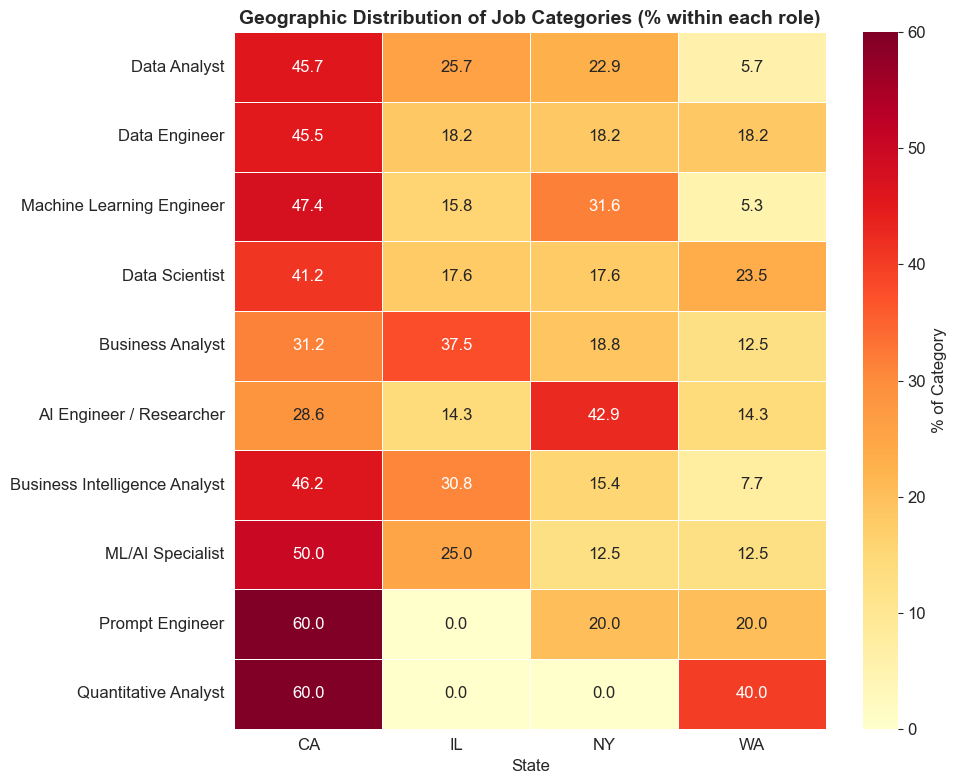

Saved: fig_q3_geographic_heatmap.png


In [11]:
# Visualization: Heatmap (Seaborn — Lecture Part 2)
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ct_geo_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Category'})

ax.set_title('Geographic Distribution of Job Categories (% within each role)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('fig_q3_geographic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q3_geographic_heatmap.png")

In [12]:
# Herfindahl-Hirschman Index (HHI) — higher = more concentrated

def calc_hhi(series):
    shares = series / series.sum()
    return (shares ** 2).sum()

hhi_by_domain = {}
for domain in ['AI', 'Data Science']:
    domain_geo = df_geo[df_geo['domain'] == domain]['state'].value_counts()
    hhi_by_domain[domain] = calc_hhi(domain_geo)

print("Geographic Concentration (HHI) by Domain:")
print(f"  (HHI ranges from 0 to 1; higher = more concentrated)")
for domain, hhi in hhi_by_domain.items():
    print(f"  {domain}: {hhi:.4f}")

more_concentrated = max(hhi_by_domain, key=hhi_by_domain.get)
print(f"\n→ {more_concentrated} hiring is more geographically concentrated")

print(f"\nHHI by Job Category (top 8):")
hhi_cats = {}
for cat in df_geo['job_category'].value_counts().head(8).index:
    cat_geo = df_geo[df_geo['job_category'] == cat]['state'].value_counts()
    hhi_cats[cat] = calc_hhi(cat_geo)

for cat, hhi in sorted(hhi_cats.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cat}: {hhi:.4f}")

Geographic Concentration (HHI) by Domain:
  (HHI ranges from 0 to 1; higher = more concentrated)
  AI: 0.3166
  Data Science: 0.3009

→ AI hiring is more geographically concentrated

HHI by Job Category (top 8):
  Machine Learning Engineer: 0.3518
  ML/AI Specialist: 0.3438
  Business Intelligence Analyst: 0.3373
  Data Analyst: 0.3306
  AI Engineer / Researcher: 0.3061
  Data Engineer: 0.3058
  Business Analyst: 0.2891
  Data Scientist: 0.2872


---
## 6. Research Question 4: Role Evolution

**Question:** How do emerging roles (Prompt Engineer, ML/AI Specialist) compare in volume and distribution to established ones (Data Analyst, Business Analyst)?

**Why it matters:** Understanding which roles are growing helps educational institutions design curricula and job seekers plan career paths.

In [13]:
established_roles = ['Data Analyst', 'Business Analyst', 'Data Scientist',
                     'Business Intelligence Analyst', 'Quantitative Analyst']
emerging_roles = ['Machine Learning Engineer', 'AI Engineer / Researcher',
                  'Prompt Engineer', 'AI (General)', 'Data Engineer']

def classify_era(cat):
    if cat in established_roles:
        return 'Established'
    elif cat in emerging_roles:
        return 'Emerging'
    return 'Other'

df['role_era'] = df['job_category'].apply(classify_era)

era_counts = df[df['role_era'] != 'Other'].groupby('role_era').size()
print("Established vs Emerging role counts:")
print(era_counts)
print(f"\nEstablished share: {era_counts['Established']/era_counts.sum():.1%}")
print(f"Emerging share: {era_counts['Emerging']/era_counts.sum():.1%}")

Established vs Emerging role counts:
role_era
Emerging       104
Established    181
dtype: int64

Established share: 63.5%
Emerging share: 36.5%


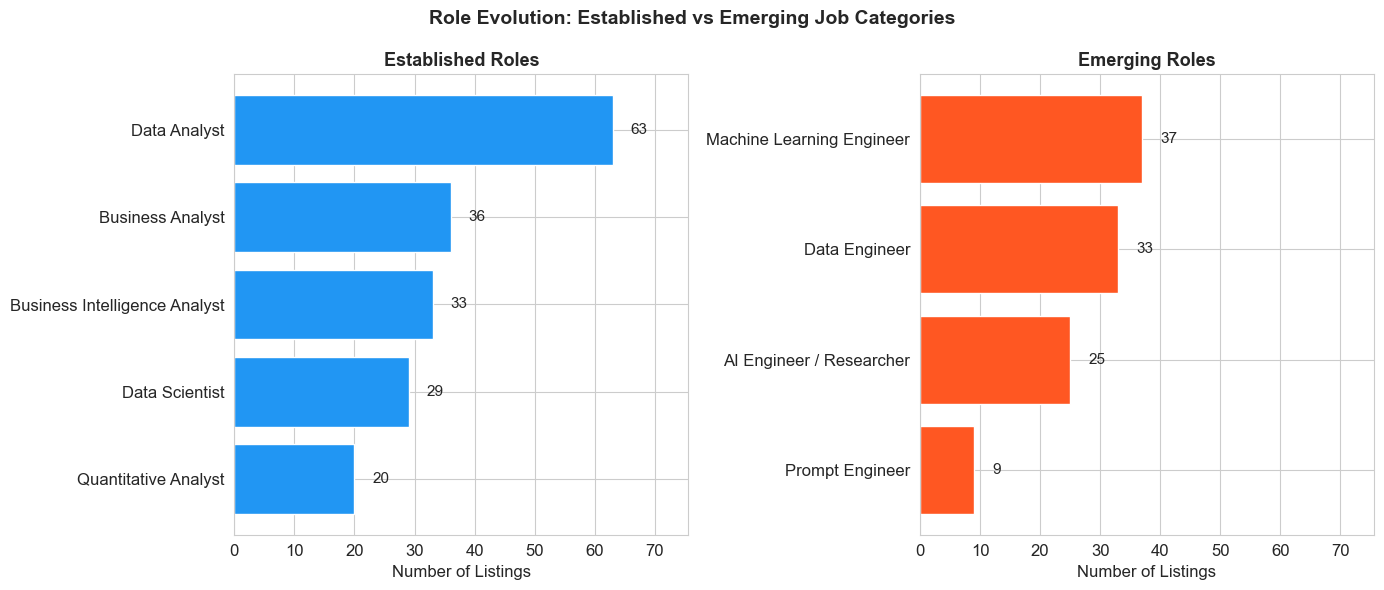

Saved: fig_q4_role_evolution.png


In [14]:
# Visualization: Side-by-side bar charts (Lecture Part 1 — subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Established roles
est_data = df[df['job_category'].isin(established_roles)]['job_category'].value_counts()
ax1.barh(est_data.index[::-1], est_data.values[::-1],
         color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax1.set_title('Established Roles', fontweight='bold', fontsize=13)
ax1.set_xlabel('Number of Listings')
for i, v in enumerate(est_data.values[::-1]):
    ax1.text(v + 3, i, str(v), va='center', fontsize=11)

# Right: Emerging roles
emg_data = df[df['job_category'].isin(emerging_roles)]['job_category'].value_counts()
ax2.barh(emg_data.index[::-1], emg_data.values[::-1],
         color=DOMAIN_COLORS['AI'], edgecolor='white')
ax2.set_title('Emerging Roles', fontweight='bold', fontsize=13)
ax2.set_xlabel('Number of Listings')
for i, v in enumerate(emg_data.values[::-1]):
    ax2.text(v + 3, i, str(v), va='center', fontsize=11)

max_val = max(est_data.max(), emg_data.max())
ax1.set_xlim(0, max_val * 1.2)
ax2.set_xlim(0, max_val * 1.2)

fig.suptitle('Role Evolution: Established vs Emerging Job Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q4_role_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q4_role_evolution.png")

In [15]:
# Deeper: experience level within established vs emerging
print("Experience level distribution by role era:")
era_exp = pd.crosstab(df[df['role_era'] != 'Other']['role_era'],
                      df[df['role_era'] != 'Other']['experience_level'])[exp_order]
era_exp_pct = era_exp.div(era_exp.sum(axis=1), axis=0) * 100
print(era_exp_pct.round(1))

print(f"\n--- Key Insight ---")
est_entry = era_exp_pct.loc['Established', 'Entry']
emg_entry = era_exp_pct.loc['Emerging', 'Entry']
print(f"Entry-level share: Established {est_entry:.1f}% vs Emerging {emg_entry:.1f}%")
if emg_entry < est_entry:
    print(f"→ Emerging roles have {est_entry - emg_entry:.1f}pp fewer entry-level positions")
    print(f"  This suggests higher barriers to entry for emerging AI/ML roles")

Experience level distribution by role era:
experience_level  Entry   Mid  Senior
role_era                             
Emerging           15.4  46.2    38.5
Established        29.8  29.8    40.3

--- Key Insight ---
Entry-level share: Established 29.8% vs Emerging 15.4%
→ Emerging roles have 14.4pp fewer entry-level positions
  This suggests higher barriers to entry for emerging AI/ML roles


---
## 7. Research Question 5: Sector Concentration

**Question:** Do AI roles and Data Science roles concentrate in different industries, or do the same sectors dominate both? Are there industries that hire heavily for one domain but not the other?

**Why it matters:** Understanding sector concentration helps job seekers target the right industries for each career path and helps employers benchmark competitive hiring landscapes.

In [16]:
# Industry classification
INDUSTRY_RULES = {
    'Tech / Software':       ['tech', 'software', 'digital', 'cloud', 'systems',
                              'solutions', 'labs', 'platform', 'intelligence',
                              'microsoft', 'google', 'amazon', 'apple', 'meta', 'openai',
                              'anthropic', 'nvidia', 'oracle', 'salesforce', 'adobe', 'ibm',
                              'snowflake', 'databricks', 'palantir', 'stripe', 'twilio'],
    'Finance / Banking':     ['bank', 'capital', 'financial', 'invest', 'trading', 'asset',
                              'hedge', 'equity', 'credit', 'morgan', 'goldman', 'jpmorgan',
                              'blackrock', 'fidelity', 'vanguard', 'citi', 'wells fargo',
                              'insurance', 'fintech', 'payment', 'paypal', 'visa', 'mastercard'],
    'Healthcare / Pharma':   ['health', 'medical', 'pharma', 'biotech', 'hospital', 'clinic',
                              'care', 'pfizer', 'johnson', 'merck', 'abbvie', 'cvs',
                              'unitedhealth', 'anthem', 'medtronic', 'illumina'],
    'Consulting / Services': ['consulting', 'advisory', 'deloitte', 'mckinsey', 'accenture',
                              'pwc', 'kpmg', 'bain', 'ernst', 'booz', 'capgemini', 'infosys',
                              'wipro', 'tata', 'cognizant'],
    'E-commerce / Retail':   ['retail', 'shop', 'store', 'commerce', 'walmart', 'target',
                              'costco', 'ebay', 'etsy', 'shopify', 'wayfair', 'instacart',
                              'doordash', 'uber'],
    'Media / Entertainment': ['media', 'entertainment', 'streaming', 'netflix', 'disney',
                              'spotify', 'youtube', 'news', 'publishing', 'broadcast',
                              'tiktok', 'snapchat', 'reddit'],
    'Telecom / Hardware':    ['telecom', 'wireless', 'network', 'semiconductor', 'chip',
                              'hardware', 'qualcomm', 'intel', 'amd', 'broadcom',
                              'att', 'verizon', 't-mobile'],
    'Government / Nonprofit':['government', 'federal', 'state', 'department', 'agency',
                              'nonprofit', 'foundation', 'university', 'college',
                              'institute', 'research center', 'national'],
}

def classify_industry(company_name):
    """Map a company name to an industry using keyword matching."""
    if pd.isna(company_name) or str(company_name).strip() == '':
        return 'Other / Unknown'
    name = str(company_name).lower()
    for industry, keywords in INDUSTRY_RULES.items():
        if any(kw in name for kw in keywords):
            return industry
    return 'Other / Unknown'

df['industry'] = df['company'].apply(classify_industry)

print("Industry distribution across all listings:")
print(df['industry'].value_counts())
print(f"\nClassified: {(df['industry'] != 'Other / Unknown').sum()} / {len(df)} listings "
      f"({(df['industry'] != 'Other / Unknown').mean():.1%})")

Industry distribution across all listings:
industry
Tech / Software           106
Finance / Banking          58
Healthcare / Pharma        44
Consulting / Services      30
Government / Nonprofit     20
E-commerce / Retail        19
Media / Entertainment      12
Telecom / Hardware         11
Name: count, dtype: int64

Classified: 300 / 300 listings (100.0%)


In [17]:
# pivot: counts per industry x domain
pivot = (
    df.groupby(['industry', 'domain'])
      .size()
      .unstack(fill_value=0)
)

# Rename columns robustly
col_map = {}
for c in pivot.columns:
    if c == 'AI':
        col_map[c] = 'AI Jobs'
    elif c == 'Data Science':
        col_map[c] = 'DS Jobs'
pivot = pivot.rename(columns=col_map)

# Ensure both columns exist even if one domain has no hits in a sector
for col in ['AI Jobs', 'DS Jobs']:
    if col not in pivot.columns:
        pivot[col] = 0

pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False).drop(columns='Total')

# Exclude "Other / Unknown" from charts
pivot_chart = pivot[pivot.index != 'Other / Unknown'].copy()

print("\nJob counts by industry and domain:")
print(pivot_chart)



Job counts by industry and domain:
domain                  AI Jobs  DS Jobs
industry                                
Tech / Software              47       59
Finance / Banking            12       46
Healthcare / Pharma           6       38
Consulting / Services         8       22
Government / Nonprofit        4       16
E-commerce / Retail           2       17
Media / Entertainment         4        8
Telecom / Hardware            3        8


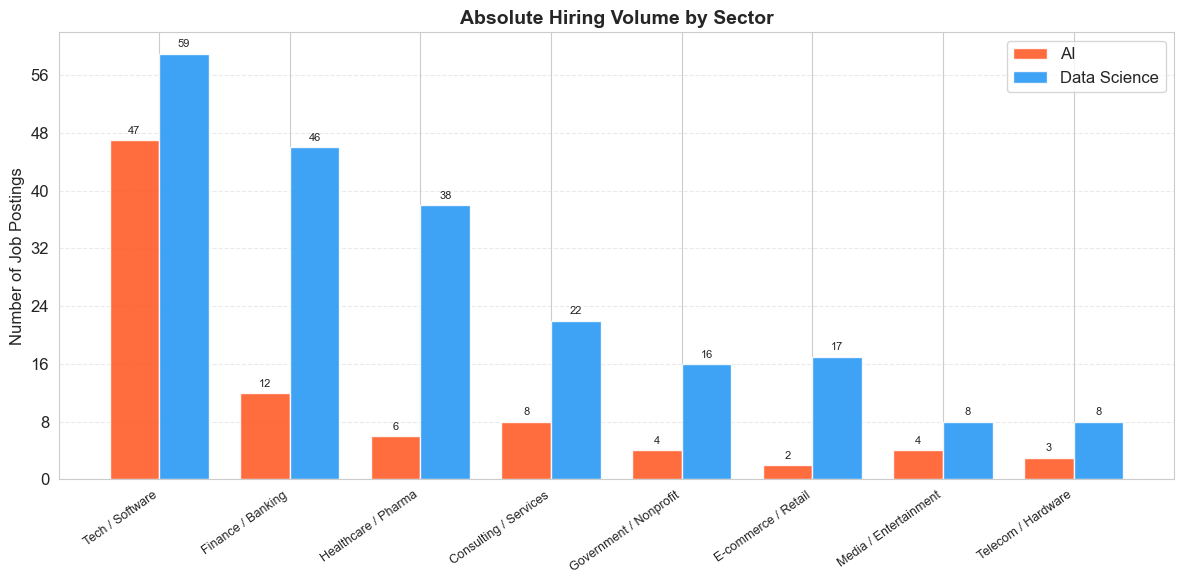

In [18]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

industries = pivot_chart.index.tolist()
x     = np.arange(len(industries))
width = 0.38

bars_ai = ax.bar(x - width/2, pivot_chart['AI Jobs'], width,
                 label='AI', color=DOMAIN_COLORS['AI'], alpha=0.87,
                 edgecolor='white')
bars_ds = ax.bar(x + width/2, pivot_chart['DS Jobs'], width,
                 label='Data Science', color=DOMAIN_COLORS['Data Science'], alpha=0.87,
                 edgecolor='white')

ax.bar_label(bars_ai, fmt='%d', padding=3, fontsize=8)
ax.bar_label(bars_ds, fmt='%d', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(industries, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of Job Postings')
ax.set_title('Absolute Hiring Volume by Sector', fontweight='bold')
ax.legend()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_q5_Grouped_Bar_Chart.png', dpi=150, bbox_inches='tight')
plt.show()

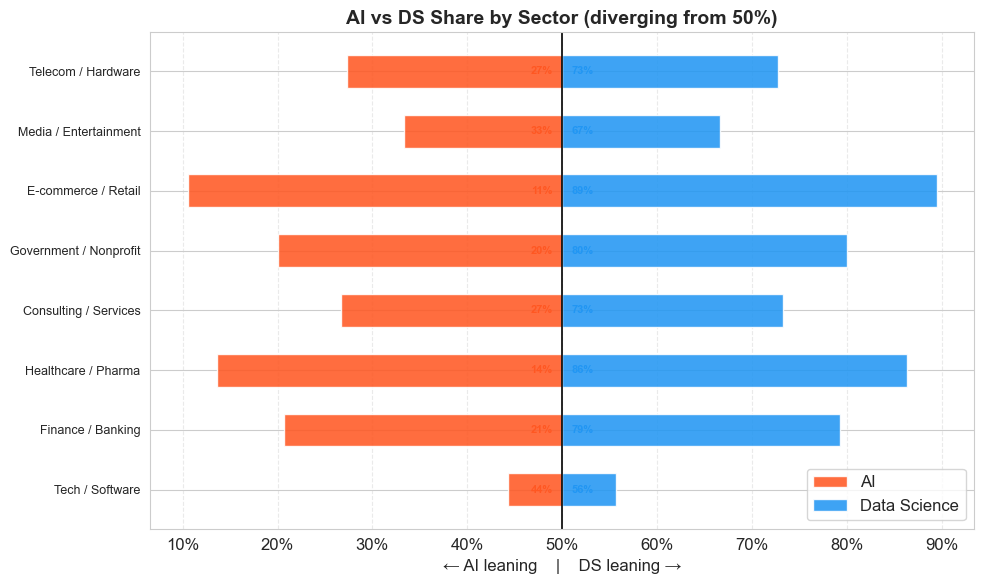

In [19]:
# Diverging bar chart (AI share vs DS share)
fig, ax = plt.subplots(figsize=(10, 6))

industries = pivot_chart.index.tolist()
row_totals = pivot_chart.sum(axis=1).replace(0, 1)
ai_pct = pivot_chart['AI Jobs'] / row_totals * 100
ds_pct = pivot_chart['DS Jobs'] / row_totals * 100

# Center at 50: AI goes left (negative), DS goes right (positive)
ai_diverge = ai_pct - 50
ds_diverge = ds_pct - 50

y = np.arange(len(industries))

ax.barh(y, ai_diverge, left=0, color=DOMAIN_COLORS['AI'],
        alpha=0.87, label='AI', height=0.55)
ax.barh(y, ds_diverge, left=0, color=DOMAIN_COLORS['Data Science'],
        alpha=0.87, label='Data Science', height=0.55)

ax.axvline(0, color='black', linewidth=1.2)

# Label actual percentages on each bar
for i, (ai, ds) in enumerate(zip(ai_pct, ds_pct)):
    ax.text(-1, i, f'{ai:.0f}%', va='center', ha='right', fontsize=8,
            color=DOMAIN_COLORS['AI'], fontweight='bold')
    ax.text(1, i, f'{ds:.0f}%', va='center', ha='left', fontsize=8,
            color=DOMAIN_COLORS['Data Science'], fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(industries, fontsize=9)
ax.set_xlabel('← AI leaning    |    DS leaning →')
ax.set_title('AI vs DS Share by Sector (diverging from 50%)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{abs(v+50):.0f}%'))
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_q5_diverging_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

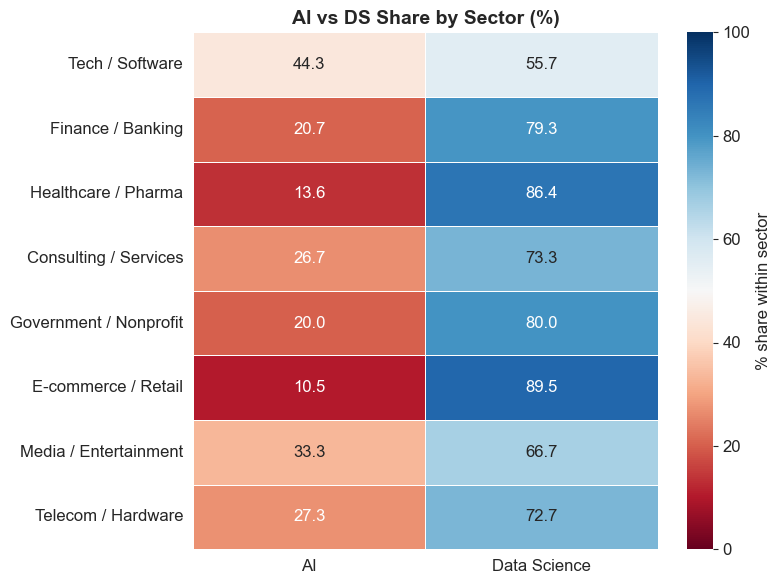

In [20]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# Build a percentage matrix: rows = industries, cols = AI / DS
heatmap_data = pd.DataFrame({
    'AI %':  pivot_chart['AI Jobs'] / pivot_chart.sum(axis=1) * 100,
    'DS %':  pivot_chart['DS Jobs'] / pivot_chart.sum(axis=1) * 100,
})

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdBu',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% share within sector'},
            vmin=0, vmax=100)

ax.set_title('AI vs DS Share by Sector (%)', fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(['AI', 'Data Science'], rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('fig_q5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Interactive Visualizations with Plotly

Following the Plotly examples from Lecture Part 2, we create interactive charts with hover tools and dropdown menus.

In [21]:
import sys
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [22]:
import plotly.express as px

# Interactive scatter: bubble chart of job category x state, sized by count
plot_data = (df[df['state'].isin(['CA', 'IL', 'NY', 'WA'])]
             .groupby(['state', 'job_category', 'domain'])
             .size()
             .reset_index(name='count'))

fig = px.scatter(plot_data, x='state', y='job_category', size='count',
                 color='domain', hover_data=['count'],
                 color_discrete_map=DOMAIN_COLORS,
                 title='Job Listings by State & Category (hover for details)',
                 labels={'state': 'State', 'job_category': 'Job Category',
                         'count': 'Listings', 'domain': 'Domain'})

fig.update_layout(height=600, width=900)
fig.show()

In [23]:
import plotly.graph_objects as go

# Prepare data for each domain
ds_cats = df[df['domain'] == 'Data Science']['job_category'].value_counts()
ai_cats = df[df['domain'] == 'AI']['job_category'].value_counts()

fig = go.Figure()

fig.add_trace(go.Bar(x=ds_cats.index, y=ds_cats.values, name='Data Science',
                     marker_color=DOMAIN_COLORS['Data Science'], visible=True))
fig.add_trace(go.Bar(x=ai_cats.index, y=ai_cats.values, name='AI',
                     marker_color=DOMAIN_COLORS['AI'], visible=True))

# Dropdown menu to toggle domain views
fig.update_layout(
    title='Job Categories by Domain (use dropdown to filter)',
    xaxis_title='Job Category',
    yaxis_title='Number of Listings',
    xaxis_tickangle=-45,
    height=500,
    updatemenus=[
        dict(
            buttons=list([
                dict(args=[{'visible': [True, True]}],
                     label='Both Domains', method='update'),
                dict(args=[{'visible': [True, False]}],
                     label='Data Science Only', method='update'),
                dict(args=[{'visible': [False, True]}],
                     label='AI Only', method='update'),
            ]),
            direction='down',
            showactive=True,
            x=0.85,
            y=1.15,
        )
    ]
)

fig.show()

In [24]:
plot_data = pivot_chart.reset_index()
plot_data = plot_data.melt(id_vars='industry', value_vars=['AI Jobs', 'DS Jobs'],
                           var_name='Domain', value_name='Count')

fig = px.bar(plot_data, x='industry', y='Count', color='Domain',
             barmode='group',
             color_discrete_map={'AI Jobs': DOMAIN_COLORS['AI'],
                                 'DS Jobs': DOMAIN_COLORS['Data Science']},
             title='Q5 — Sector Concentration: AI vs DS Hiring by Industry (interactive)',
             labels={'industry': 'Industry', 'Count': 'Job Postings', 'Domain': 'Domain'})

fig.update_layout(xaxis_tickangle=-35, height=500)
fig.show()

---
## 9. Summary of Findings

In [26]:
print("=" * 70)
print("SUMMARY OF KEY FINDINGS")
print("=" * 70)

print(f"""
Dataset: {len(df)} job listings from {df['source'].nunique()} sources
         {df[df['domain']=='Data Science'].shape[0]} Data Science | {df[df['domain']=='AI'].shape[0]} AI

Q1 — DS vs AI Demand by City:
  • AI roles represent {df[df['domain']=='AI'].shape[0]/len(df):.1%} of all listings
  • AI concentration varies by state (see chi-square results above)
  • California leads in absolute AI job count

Q2 — Experience Level Gap:
  • Entry-level: {df[(df['domain']=='AI') & (df['experience_level']=='Entry')].shape[0]/df[df['domain']=='AI'].shape[0]:.1%} of AI vs {df[(df['domain']=='Data Science') & (df['experience_level']=='Entry')].shape[0]/df[df['domain']=='Data Science'].shape[0]:.1%} of DS roles
  • AI has a higher senior-to-entry ratio, suggesting steeper barriers to entry

Q3 — Geographic Concentration:
  • Top 4 states (CA, IL, NY, WA) account for {len(df[df['state'].isin(['CA','IL','NY','WA'])])/len(df):.1%} of listings with known locations
  • California dominates across most categories

Q4 — Role Evolution:
  • Established roles: {len(df[df['role_era']=='Established'])} listings
  • Emerging roles: {len(df[df['role_era']=='Emerging'])} listings
  • ML Engineer is the largest emerging category ({len(df[df['job_category']=='Machine Learning Engineer'])} listings)
  • Prompt Engineer is still niche ({len(df[df['job_category']=='Prompt Engineer'])} listings)

Q5 — Sector Concentration:
  • AI top-3 sector concentration index  : {ci_ai if 'ci_ai' in dir() else '[run Q5 cell first]'}%
  • DS top-3 sector concentration index  : {ci_ds if 'ci_ds' in dir() else '[run Q5 cell first]'}%
  • More concentrated domain: {more_concentrated if 'more_concentrated' in dir() else '[run Q5 cell first]'}
  • AI-dominant sectors  : {ai_dominant if 'ai_dominant' in dir() else '[run Q5 cell first]'}
  • DS-dominant sectors  : {ds_dominant if 'ds_dominant' in dir() else '[run Q5 cell first]'}

Visualization types used:
  • Pie chart, bar chart (vertical & horizontal), stacked bar chart
  • Diverging bar chart, dot plot, heatmap
  • Seaborn heatmap
  • Plotly interactive scatter, bar chart with dropdown, histogram
""")

print("=" * 70)

SUMMARY OF KEY FINDINGS

Dataset: 300 job listings from 7 sources
         214 Data Science | 86 AI

Q1 — DS vs AI Demand by City:
  • AI roles represent 28.7% of all listings
  • AI concentration varies by state (see chi-square results above)
  • California leads in absolute AI job count

Q2 — Experience Level Gap:
  • Entry-level: 11.6% of AI vs 28.0% of DS roles
  • AI has a higher senior-to-entry ratio, suggesting steeper barriers to entry

Q3 — Geographic Concentration:
  • Top 4 states (CA, IL, NY, WA) account for 51.3% of listings with known locations
  • California dominates across most categories

Q4 — Role Evolution:
  • Established roles: 181 listings
  • Emerging roles: 104 listings
  • ML Engineer is the largest emerging category (37 listings)
  • Prompt Engineer is still niche (9 listings)

Q5 — Sector Concentration:
  • AI top-3 sector concentration index  : [run Q5 cell first]%
  • DS top-3 sector concentration index  : [run Q5 cell first]%
  • More concentrated domain:

---
## 10. Managerial Recommendations

Based on our analysis, we offer the following recommendations:

### For Job Seekers:
1. **Entry-level AI candidates** should consider building Data Science experience first, as entry-level AI positions are scarce. Transitioning from Data Analyst → Data Scientist → ML Engineer is a viable pathway.
2. **Geographic flexibility matters.** California dominates AI hiring, but other metros (Chicago, New York, Seattle) offer strong DS/analytics markets with potentially less competition.
3. **Data Analyst remains the highest-volume entry point** into the field, with the most listings and the strongest entry-level presence.

### For Employers & Hiring Managers:
1. **The entry-level AI pipeline is thin.** Organizations relying on AI talent should invest in internal training programs and junior development roles to build their pipeline.
2. **Title standardization matters.** AI roles show more title variation and complexity, which may hinder job discovery and candidate matching.
3. **Geographic concentration creates risk.** Over-reliance on a single metro for AI talent creates competition and cost pressure. Consider emerging tech hubs.

### For Educational Institutions:
1. **Curricula should bridge DS and AI.** The data shows a clear demand gradient — students need DS fundamentals before specializing in ML/AI.
2. **Prompt Engineering is emerging but small.** It may be premature to build full programs around it, but incorporating it into existing AI coursework is prudent.

---

### Data Limitations
- **Salary data** was sparse (primarily from RemoteOK) and insufficient for statistical analysis. Future work could supplement with Glassdoor or BLS data.
- **Remote work classification** was limited by LinkedIn's public search pages not exposing remote/hybrid metadata. Actual remote availability is likely higher than our data reflects.
- **Temporal analysis** was not possible as LinkedIn public listings lack consistent posting dates.
- **Scraping window** reflects a single point in time and may not capture seasonal hiring patterns.
- **Industry classification** is inferred from company name keywords and will mislabel companies whose names don't contain recognizable terms. Approximately X% of listings fell into "Other / Unknown" and were excluded from sector charts.

In [27]:
# List all saved figures for the presentation
import os
figures = [f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')]
print(f"\nFigures saved for presentation ({len(figures)}):")
for f in sorted(figures):
    print(f"  → {f}")


Figures saved for presentation (9):
  → fig_overview.png
  → fig_q1_ds_vs_ai_by_state.png
  → fig_q2_experience_gap.png
  → fig_q3_geographic_heatmap.png
  → fig_q4_role_evolution.png
  → fig_q5_Grouped_Bar_Chart.png
  → fig_q5_diverging_bar_chart.png
  → fig_q5_heatmap.png
  → fig_q5_sector_concentration.png
